In [101]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from utilsforecast.plotting import plot_series
from utilsforecast.evaluation import evaluate
from utilsforecast.losses import *
from sklearn.metrics import mean_absolute_error, mean_squared_error

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima_model import ARIMA
import statsmodels.api as sm

import warnings
warnings.filterwarnings('ignore')

In [4]:
df = pd.read_csv("C:/Users/h/OneDrive/Desktop/archive/Month_Value_1.csv")
df.rename(columns={'Period': 'Date'}, inplace=True)
df.head()

,Date,Revenue,Sales_quantity,Average_cost,The_average_annual_payroll_of_the_region
0,01.01.2015,1.601007e+07,12729.0,1257.763541,30024676.0
1,01.02.2015,1.580759e+07,11636.0,1358.507000,30024676.0
2,01.03.2015,2.204715e+07,15922.0,1384.697024,30024676.0
3,01.04.2015,1.881458e+07,15227.0,1235.606705,30024676.0
4,01.05.2015,1.402148e+07,8620.0,1626.621765,30024676.0


In [5]:
df.describe()

,Revenue,Sales_quantity,Average_cost,The_average_annual_payroll_of_the_region
count,6.400000e+01,64.000000,64.000000,6.400000e+01
mean,3.236045e+07,19197.375000,1695.061159,2.869083e+07
std,1.164150e+07,6591.287257,296.844793,1.057191e+06
min,1.402148e+07,8314.000000,1110.576805,2.740647e+07
25%,2.242655e+07,15065.500000,1499.142841,2.782857e+07
50%,3.209088e+07,18368.000000,1654.399798,2.819785e+07
75%,3.992999e+07,22856.250000,1916.401096,2.987852e+07
max,5.875647e+07,38069.000000,2559.328184,3.002468e+07


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96 entries, 0 to 95
Data columns (total 5 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Date                                      96 non-null     object 
 1   Revenue                                   64 non-null     float64
 2   Sales_quantity                            64 non-null     float64
 3   Average_cost                              64 non-null     float64
 4   The_average_annual_payroll_of_the_region  64 non-null     float64
dtypes: float64(4), object(1)
memory usage: 3.9+ KB


In [7]:
df.isnull().sum()

Date                                         0
Revenue                                     32
Sales_quantity                              32
Average_cost                                32
The_average_annual_payroll_of_the_region    32
dtype: int64

In [8]:
data = df[df["Revenue"].notnull()]
data.isnull().sum()

Date                                        0
Revenue                                     0
Sales_quantity                              0
Average_cost                                0
The_average_annual_payroll_of_the_region    0
dtype: int64

In [9]:
data

,Date,Revenue,Sales_quantity,Average_cost,The_average_annual_payroll_of_the_region
0,01.01.2015,1.601007e+07,12729.0,1257.763541,30024676.0
1,01.02.2015,1.580759e+07,11636.0,1358.507000,30024676.0
2,01.03.2015,2.204715e+07,15922.0,1384.697024,30024676.0
3,01.04.2015,1.881458e+07,15227.0,1235.606705,30024676.0
4,01.05.2015,1.402148e+07,8620.0,1626.621765,30024676.0
...,...,...,...,...,...
59,01.12.2019,5.875647e+07,38069.0,1543.420464,29878525.0
60,01.01.2020,5.628830e+07,27184.0,2070.640850,29044998.0
61,01.02.2020,4.022524e+07,23509.0,1711.057181,29044998.0
62,01.03.2020,5.002217e+07,32569.0,1535.882748,29044998.0


In [11]:
data['Date'].astype('datetime64[ns]')
data['Date'] = pd.to_datetime(data['Date'], format='%d.%m.%Y')

In [12]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 64 entries, 0 to 63
Data columns (total 5 columns):
 #   Column                                    Non-Null Count  Dtype         
---  ------                                    --------------  -----         
 0   Date                                      64 non-null     datetime64[ns]
 1   Revenue                                   64 non-null     float64       
 2   Sales_quantity                            64 non-null     float64       
 3   Average_cost                              64 non-null     float64       
 4   The_average_annual_payroll_of_the_region  64 non-null     float64       
dtypes: datetime64[ns](1), float64(4)
memory usage: 3.0 KB


In [14]:
data['year'] = data['Date'].dt.year
data['month'] = data['Date'].dt.month
data['day'] = data['Date'].dt.day
data['dayofweek'] = data['Date'].dt.day_of_week

data.head()

,Date,Revenue,Sales_quantity,Average_cost,The_average_annual_payroll_of_the_region,year,month,day,dayofweek
0,2015-01-01,1.601007e+07,12729.0,1257.763541,30024676.0,2015,1,1,3
1,2015-02-01,1.580759e+07,11636.0,1358.507000,30024676.0,2015,2,1,6
2,2015-03-01,2.204715e+07,15922.0,1384.697024,30024676.0,2015,3,1,6
3,2015-04-01,1.881458e+07,15227.0,1235.606705,30024676.0,2015,4,1,2
4,2015-05-01,1.402148e+07,8620.0,1626.621765,30024676.0,2015,5,1,4


Text(0.5, 1.0, 'Sales Quantity')

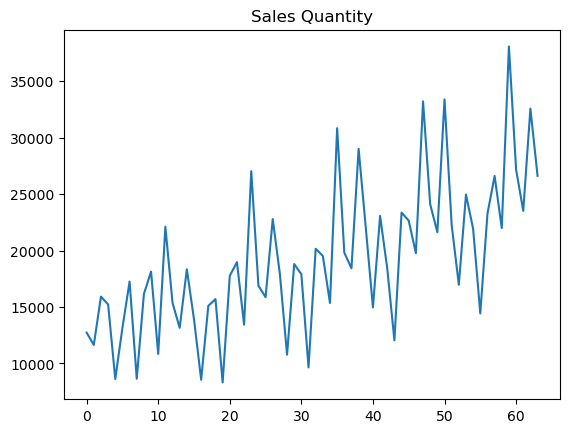

In [20]:
plt.plot(data['Sales_quantity'])
plt.title('Sales Quantity')

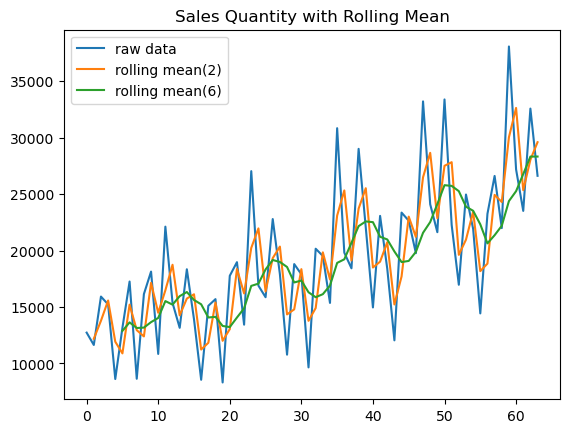

In [21]:
data['rolling_mean'] = data['Sales_quantity'].rolling(window=2).mean()
data['rolling_mean6'] = data['Sales_quantity'].rolling(window=6).mean()
plt.plot(data['Sales_quantity'], label='raw data')
plt.plot(data['rolling_mean'], label='rolling mean(2)')
plt.plot(data['rolling_mean6'], label='rolling mean(6)')
plt.title('Sales Quantity with Rolling Mean')
plt.legend(loc='best')

Text(0.5, 1.0, 'Revenue')

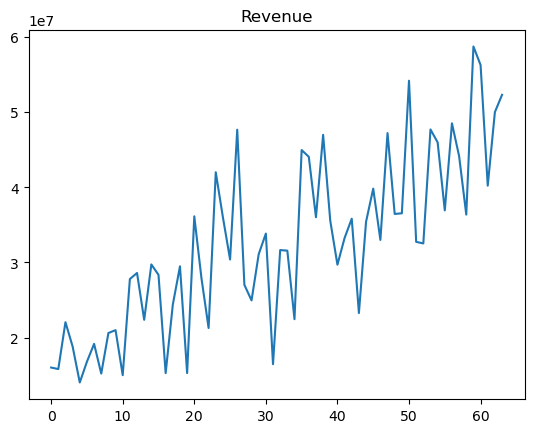

In [23]:
plt.plot(data['Revenue'])
plt.title('Revenue')

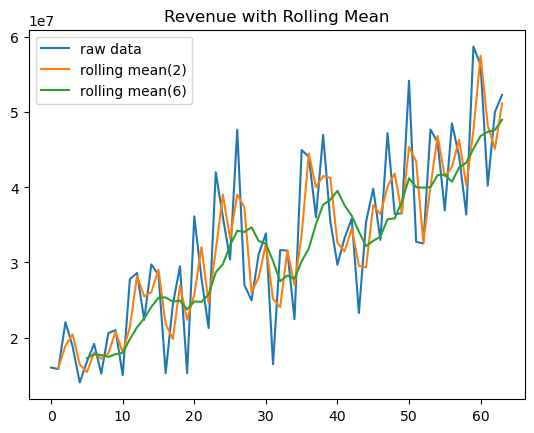

In [26]:
data['rev_rolling_mean'] = data['Revenue'].rolling(window=2).mean()
data['rev_rolling_mean6'] = data['Revenue'].rolling(window=6).mean()
plt.plot(data['Revenue'], label='raw data')
plt.plot(data['rev_rolling_mean'], label='rolling mean(2)')
plt.plot(data['rev_rolling_mean6'], label='rolling mean(6)')
plt.title('Revenue with Rolling Mean')
plt.legend(loc='best')

(array([ 7.,  8.,  4., 11., 12.,  5.,  4.,  6.,  3.,  2.]),
 array([14021479.611678  , 18494979.0165902 , 22968478.4215024 ,
        27441977.8264146 , 31915477.2313268 , 36388976.63623901,
        40862476.04115121, 45335975.44606341, 49809474.8509756 ,
        54282974.25588781, 58756473.6608    ]),
 <BarContainer object of 10 artists>)

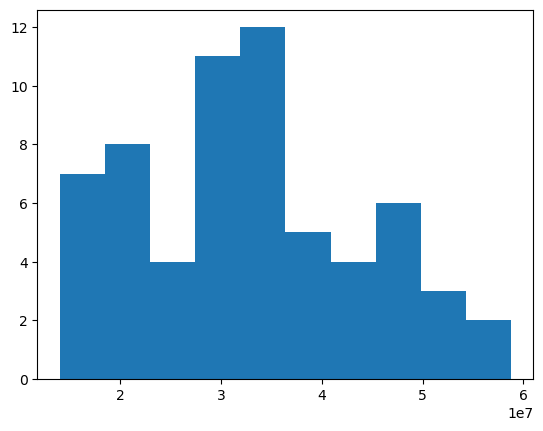

In [89]:
plt.hist(data['Revenue'], bins=10)

{'whiskers': [<matplotlib.lines.Line2D at 0x192ef777a90>,
 'caps': [<matplotlib.lines.Line2D at 0x192f10eac50>,
 'boxes': [<matplotlib.lines.Line2D at 0x192f0e51190>],
 'medians': [<matplotlib.lines.Line2D at 0x192f10ebd10>],
 'fliers': [<matplotlib.lines.Line2D at 0x192f10fc550>],
 'means': []}

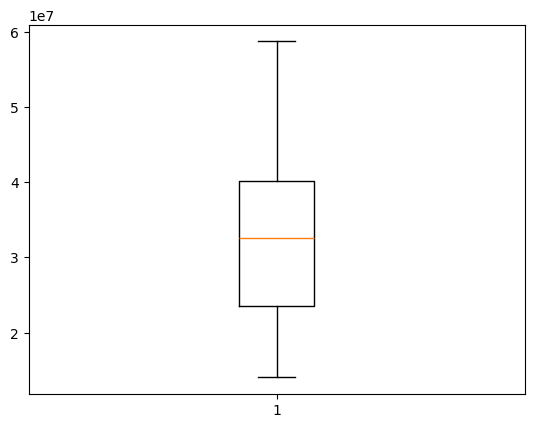

In [90]:
plt.boxplot(data['Revenue'])

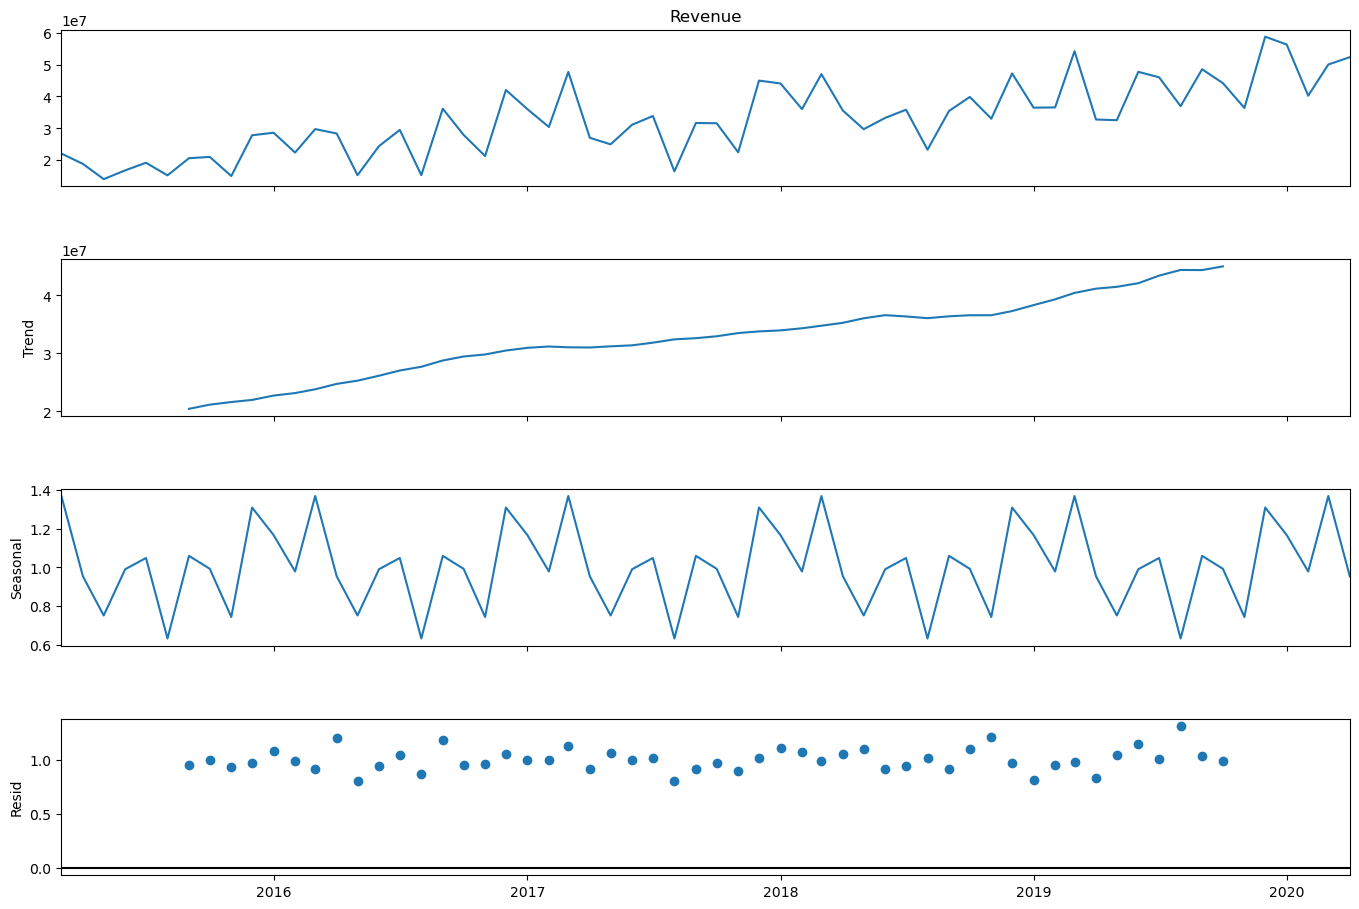

In [92]:
result = seasonal_decompose(data['Revenue'], model='multiplicative', period=12)
fig=result.plot()
fig.set_size_inches(15,10)

In [93]:
train = data['Revenue'].iloc[:-12]
test = data['Revenue'].iloc[-12:]

In [94]:
train.shape, test.shape

((50,), (12,))

In [97]:
model = sm.tsa.statespace.SARIMAX(
    train,
    order=(1,1,1),
    seasonal_order=(1,1,1,12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

result = model.fit()
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                            Revenue   No. Observations:                   50
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -385.134
Date:                            Thu, 26 Mar 2026   AIC                            780.267
Time:                                    18:09:28   BIC                            785.945
Sample:                                03-01-2015   HQIC                           781.695
                                     - 04-01-2019                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0707      1.498      0.047      0.962      -2.865       3.006
ma.L1         -0.5076      1.239     -0.410      0.682      -2.935       1.920
ar.S.L12      -0.9441      1.034     -0.913      0.361      -2.971       1.083
ma.S.L12       0.5757      1.038      0.554      0.579      -1.460       2.611
sigma2      3.543e+13   1.64e-14   2.16e+27      0.000    3.54e+13    3.54e+13
===================================================================================
Ljung-Box (L1) (Q):                   0.02   Jarque-Bera (JB):                 1.04
Prob(Q):                              0.90   Prob(JB):                         0.59
Heteroskedasticity (H):               2.24   Skew:                            -0.40
Prob(H) (two-sided):                  0.27   Kurtosis:                         2.32
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 2.72e+44. Standard errors may be unstable.
"""

In [98]:
predictions = result.predict(len(data), len(data)+7)

In [99]:
fc_mean = result.forecast(steps=7)
fc_mean

2019-05-01    3.205244e+07
2019-06-01    3.540917e+07
2019-07-01    3.738095e+07
2019-08-01    2.334211e+07
2019-09-01    3.390377e+07
2019-10-01    3.946652e+07
2019-11-01    3.091943e+07
Freq: MS, Name: predicted_mean, dtype: float64

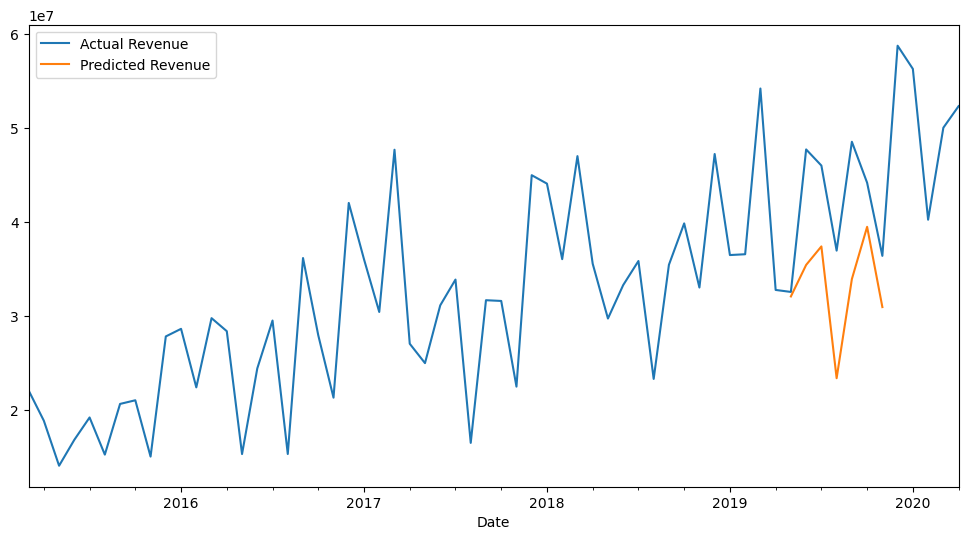

In [100]:
plt.figure(figsize=(12,6))
data['Revenue'].plot(label='Actual Revenue')
fc_mean.plot(label='Predicted Revenue')
plt.legend()
plt.show()

In [103]:
pred = result.predict(start=test.index[0], end=test.index[-1])
mae = mean_absolute_error(test, pred)
rmse = np.sqrt(mean_squared_error(test, pred))
mape = np.mean(np.abs((test-pred)/test))*100

print('MAE: ', mae)
print('RMSE: ', rmse)
print('MAPE: ', mape)

MAE:  8274716.008230038
RMSE:  9866841.950682793
MAPE:  17.563459868251172


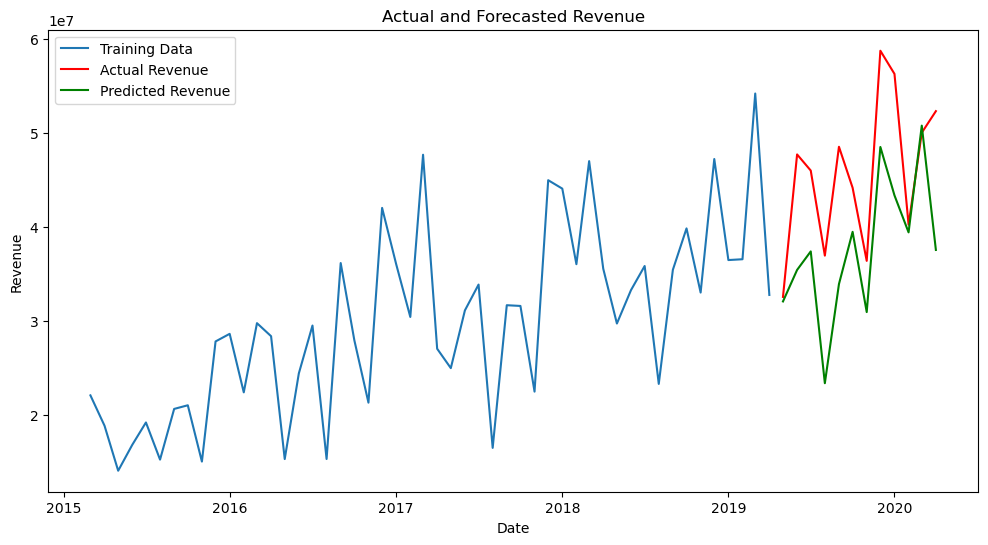

In [106]:
plt.figure(figsize=(12,6))
plt.plot(train.index, train, label='Training Data')
plt.plot(test.index, test, label='Actual Revenue', color='r')
plt.plot(pred.index, pred, label='Predicted Revenue', color='g')
plt.title('Actual and Forecasted Revenue')
plt.xlabel('Date')
plt.ylabel('Revenue')
plt.legend()
plt.show()


In [27]:
data.index = data['Date']

In [30]:
adftest = adfuller(data['Sales_quantity'], autolag='AIC') 
adftest

(1.1570562060945373,
 0.9956753282590142,
 11,
 52,
 {'1%': -3.562878534649522,
  '5%': -2.918973284023669,
  '10%': -2.597393446745562},
 936.0262923313308)

In [31]:
adfoutput = pd.Series(adftest[0:4], index=['ADF Statistics', 'p-value', '#Lags Used', 'Number of Observations Used'])
for key, value in adftest[4].items():
    adfoutput['Critical Value (%s)'%key] = value
print(adfoutput)

ADF Statistics                  1.157056
p-value                         0.995675
#Lags Used                     11.000000
Number of Observations Used    52.000000
Critical Value (1%)            -3.562879
Critical Value (5%)            -2.918973
Critical Value (10%)           -2.597393
dtype: float64


In [47]:
data['Sales_quantity'].shift(1)

Date
2015-01-01        NaN
2015-02-01    12729.0
2015-03-01    11636.0
2015-04-01    15922.0
2015-05-01    15227.0
               ...   
2019-12-01    21987.0
2020-01-01    38069.0
2020-02-01    27184.0
2020-03-01    23509.0
2020-04-01    32569.0
Name: Sales_quantity, Length: 64, dtype: float64

<Axes: xlabel='Date'>

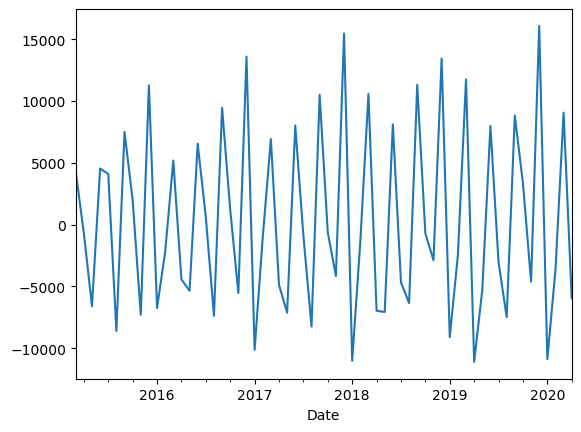

In [ ]:
#Differencing
# Remove Trend

data['#Sales_quantity'] = data['Sales_quantity'] - data['Sales_quantity'].shift(1)
data['#Sales_quantity'].dropna(inplace=True)
data = data[data['#Sales_quantity'].notnull()]
data['#Sales_quantity'].dropna().plot()

In [59]:
adftest= adfuller(data['#Sales_quantity'], autolag='AIC')
adfoutput = pd.Series(adftest[0:4], index=['ADF Statistics', 'p-value', '#Lags Used', 'Number of Observations Used'])
for key, value in adftest[4].items():
    adfoutput['Critical Value (%s)'%key] = np.round(value,1)
print(adfoutput)

adftest[1].round(4)


ADF Statistics                -8.860905e+00
p-value                        1.483842e-14
#Lags Used                     1.000000e+01
Number of Observations Used    5.100000e+01
Critical Value (1%)           -3.600000e+00
Critical Value (5%)           -2.900000e+00
Critical Value (10%)          -2.600000e+00
dtype: float64


0.0

In [66]:
# Remove Seasonality

data['#Sales_quantity_season'] = data['#Sales_quantity'] - data['#Sales_quantity'].shift(12)
data['#Sales_quantity_season'].dropna(how='any', inplace=True)
data['#Sales_quantity_season'].dropna(how='any', inplace=True).plot()

AttributeError: 'NoneType' object has no attribute 'plot'

In [65]:
data['#Sales_quantity_season']

Date
2015-03-01       NaN
2015-04-01       NaN
2015-05-01       NaN
2015-06-01       NaN
2015-07-01       NaN
               ...  
2019-12-01    2640.0
2020-01-01   -1774.0
2020-02-01   -1203.0
2020-03-01   -2695.0
2020-04-01    5160.0
Name: #Sales_quantity_season, Length: 62, dtype: float64